In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
from cns.process.binning import group_bins, sum_cns
from cns.utils.selection import get_cns_for_type
from cns.display.plot import fig_lines, plot_lines
from cns.data_utils import load_merged_samples, load_merged_bins, select_CNS_samples

In [10]:
samples_df = load_merged_samples()
# cns_df = load_merged_bins(samples_df, "3MB")

In [11]:
samples_df["type"].value_counts()

type
LUAD    1129
BRCA    1074
LUSC     844
OV       601
GBM      471
SKCM     446
HNSC     434
UCEC     430
PRAD     410
LGG      408
KIRC     406
STAD     387
BLCA     361
COAD     351
LIHC     317
CESC     284
LIRI     245
PACA     230
SARC     223
KIRP     215
ESCA     168
PBCA     164
READ     142
TGCT     140
PAAD     136
THCA     134
PCPG     119
MALY      98
ESAD      93
LAML      92
ACC       88
MESO      79
UVM       75
MELA      68
RECA      61
UCS       55
BOCA      55
PAEN      53
THYM      48
KICH      47
CLLE      47
DLBC      43
LINC      28
GACA      26
EOPC      25
CHOL      20
CMDI      16
ORCA      13
BTCA      12
LICA       5
Name: count, dtype: int64

Text(0.5, 1.0, 'The joint set of 11417 samples')

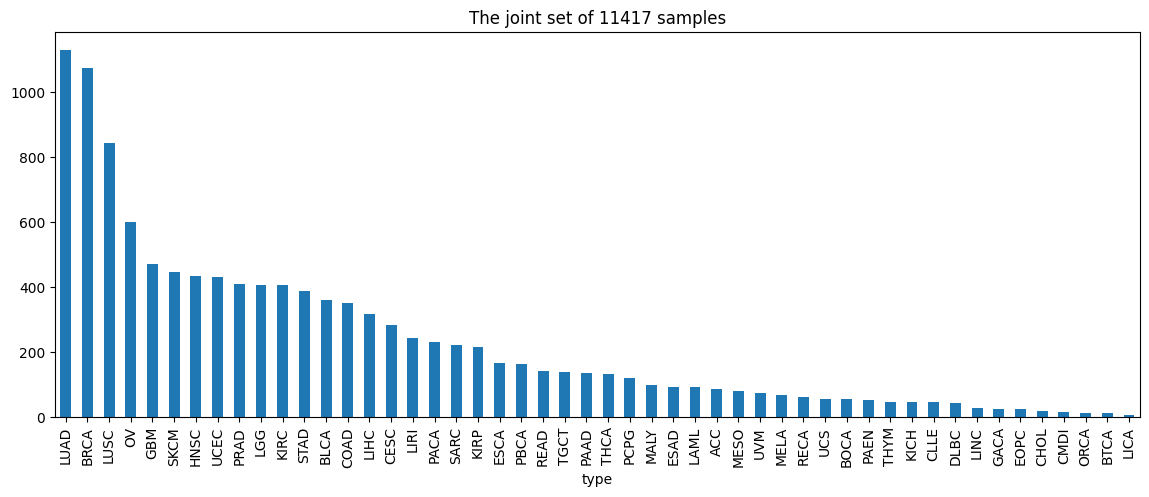

In [13]:
plt.rcParams["figure.figsize"] = (14,5)
samples_df["type"].value_counts().plot(kind="bar")
plt.title("The joint set of {} samples".format(len(samples_df)))

(<Figure size 3600x600 with 1 Axes>,
 <Axes: xlabel='position on linear genome', ylabel='mean CN per bin'>)

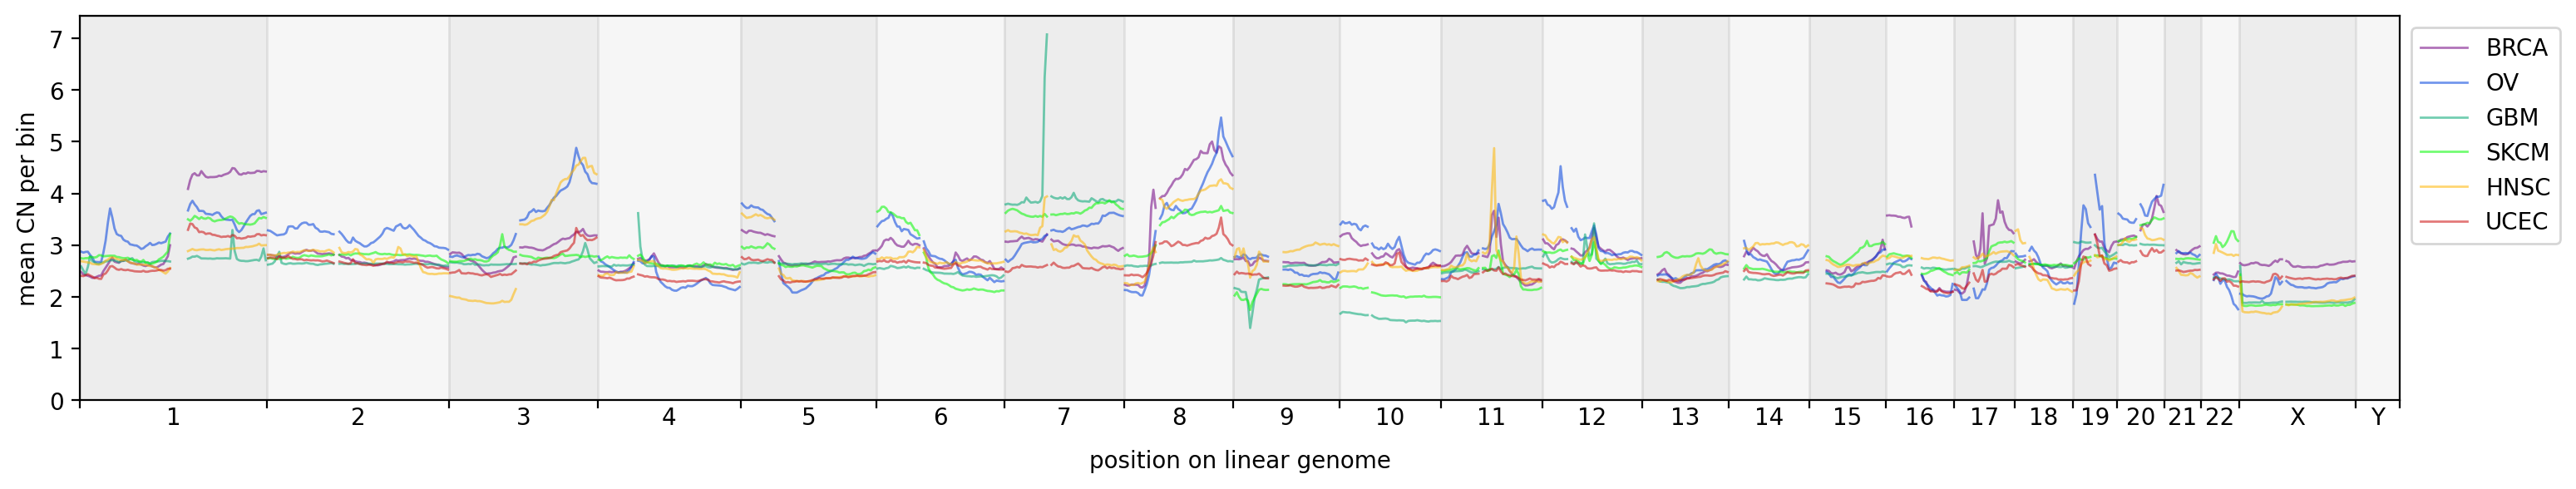

In [5]:
tcga_set = samples_df.query("source == 'TCGA'")
tcga_cns = select_CNS_samples(cns_df, tcga_set)
top_6 = tcga_set.value_counts("type")[:6].index.values
selection_tcga = [group_bins(get_cns_for_type(cns_df, samples_df, type)) for type in top_6]
fig_lines(selection_tcga, top_6, column="total_cn", dpi=200)

(<Figure size 1800x300 with 1 Axes>,
 <Axes: xlabel='position on linear genome', ylabel='mean CN per bin'>)

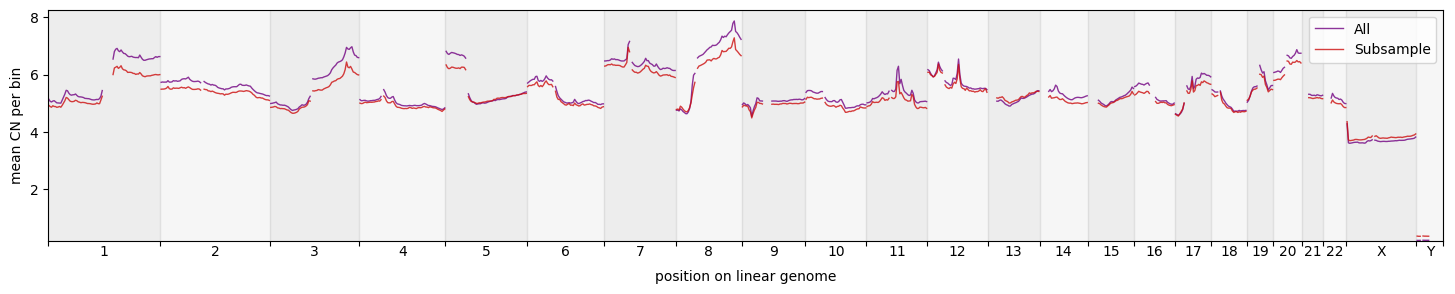

In [6]:
above_50 = samples_df["type"].value_counts().where(lambda x: x >= 50).where(lambda x: x != "Other").dropna().index.values
all_samples = samples_df.query("type in @above_50")
sub_samples = all_samples.groupby('type').apply(lambda x: x.sample(n=50, replace=True) if len(x) > 50 else x, include_groups=False).reset_index().set_index('sample_id')
# select only 50 samples for each type to obtain balanced mean
selection = [sum_cns(group_bins(select_CNS_samples(cns_df, samples))) for samples in [all_samples, sub_samples]]
fig_lines(selection, ["All", "Subsample"], column="total_cn", dpi=100)
